# Chapter 16: Machine Learning Asset Allocation

**AFML Ch. 16** -- Hierarchical Risk Parity and allocation methods.

Mean-variance optimization is highly sensitive to estimation errors in
the covariance matrix. Hierarchical Risk Parity (HRP) uses hierarchical
clustering on the correlation matrix to build portfolios that are more
stable and better diversified. This notebook compares HRP to the
Critical Line Algorithm (CLA) and Inverse Variance Portfolio (IVP).

This notebook demonstrates:

- Hierarchical Risk Parity (HRP) weights
- Critical Line Algorithm (CLA) minimum-variance portfolio
- CLA maximum Sharpe ratio portfolio
- Inverse Variance Portfolio (IVP)
- Monte Carlo comparison of allocation methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
np.random.seed(42)

## Generate Correlated Asset Returns

We simulate 6 assets with a block-diagonal correlation structure:
assets 0-2 form one cluster (equities) and assets 3-5 form another
(bonds), with moderate cross-cluster correlation.

In [2]:
n_periods = 500
n_assets = 6
asset_names = ['Equity A', 'Equity B', 'Equity C', 'Bond X', 'Bond Y', 'Bond Z']

# Block correlation matrix
corr = np.eye(n_assets)
# Equity cluster (high intra-correlation)
for i in range(3):
    for j in range(3):
        if i != j:
            corr[i, j] = 0.7
# Bond cluster (moderate intra-correlation)
for i in range(3, 6):
    for j in range(3, 6):
        if i != j:
            corr[i, j] = 0.5
# Cross-cluster (low correlation)
for i in range(3):
    for j in range(3, 6):
        corr[i, j] = 0.1
        corr[j, i] = 0.1

# Volatilities: equities higher than bonds
vols = np.array([0.20, 0.22, 0.18, 0.05, 0.06, 0.04]) / np.sqrt(252)
cov = np.outer(vols, vols) * corr

# Cholesky decomposition to generate correlated returns
L = np.linalg.cholesky(cov)
returns = (L @ np.random.randn(n_assets, n_periods)).T
# Add small positive drift
returns += np.array([0.0004, 0.0003, 0.0005, 0.0001, 0.00015, 0.0001])

print(f"Generated {n_periods} periods x {n_assets} assets")
print(f"\nAnnualized returns:")
for i, name in enumerate(asset_names):
    ann_ret = np.mean(returns[:, i]) * 252
    ann_vol = np.std(returns[:, i]) * np.sqrt(252)
    print(f"  {name:>10}: return={ann_ret:>7.2%}, vol={ann_vol:>7.2%}")

Generated 500 periods x 6 assets

Annualized returns:
    Equity A: return= 12.25%, vol= 19.61%
    Equity B: return= 17.17%, vol= 20.70%
    Equity C: return= 36.82%, vol= 17.37%
      Bond X: return=  5.53%, vol=  4.94%
      Bond Y: return=  4.86%, vol=  5.57%
      Bond Z: return=  4.86%, vol=  3.98%


### Visualisation: Correlation Matrix

The block structure is visible: equities are highly correlated with
each other, bonds form a separate cluster, and cross-cluster
correlations are low.

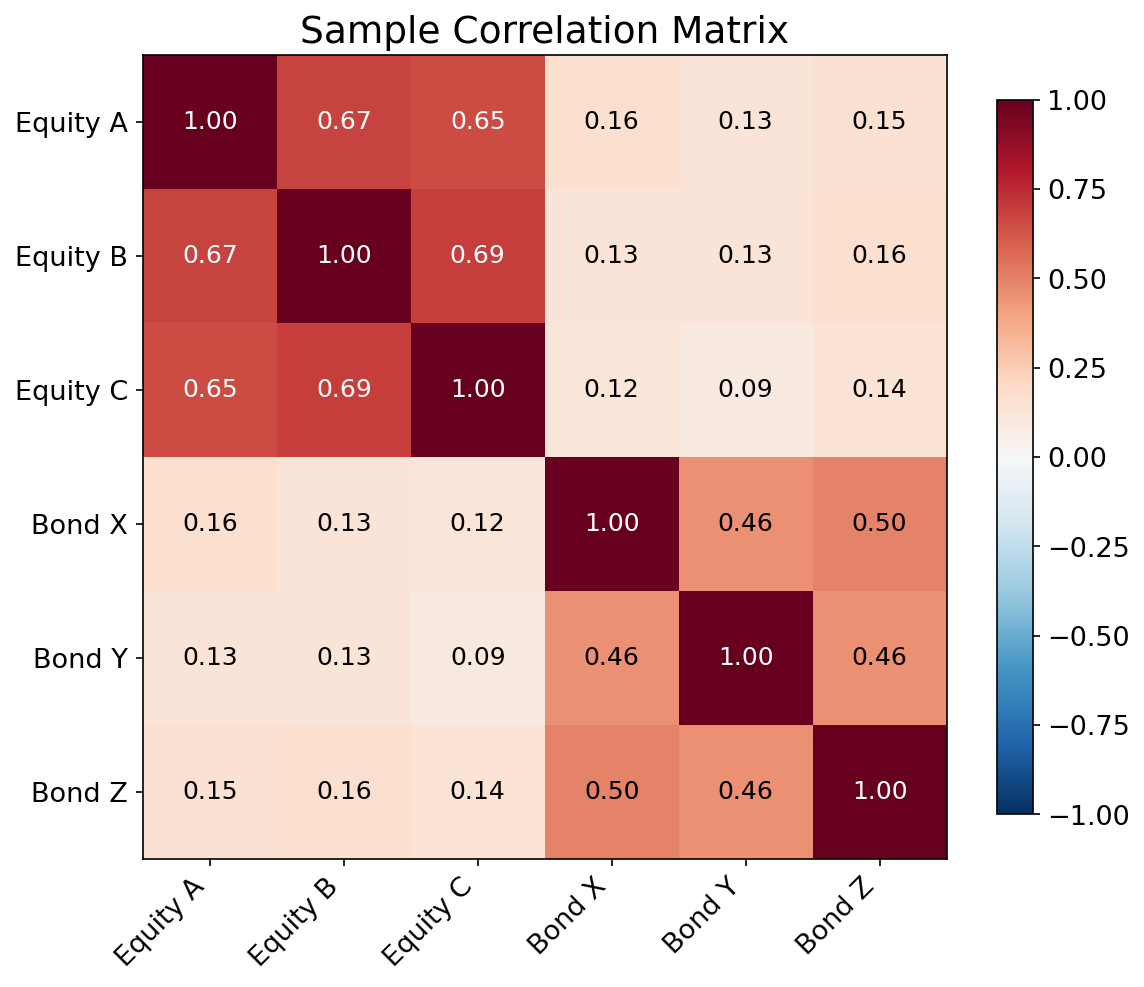

In [3]:
sample_corr = np.corrcoef(returns.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sample_corr, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(n_assets):
    for j in range(n_assets):
        ax.text(j, i, f'{sample_corr[i, j]:.2f}', ha='center', va='center',
                fontsize=12, color='white' if abs(sample_corr[i, j]) > 0.5 else 'black')
ax.set_xticks(range(n_assets))
ax.set_yticks(range(n_assets))
ax.set_xticklabels(asset_names, rotation=45, ha='right')
ax.set_yticklabels(asset_names)
ax.set_title('Sample Correlation Matrix')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Hierarchical Risk Parity (HRP)

HRP uses three steps:

1. **Tree clustering** -- build a dendrogram from the correlation distance
   matrix using single-linkage clustering.
2. **Quasi-diagonalization** -- reorder assets so that correlated ones
   are adjacent along the diagonal.
3. **Recursive bisection** -- allocate inversely proportional to cluster
   variance, recursively splitting the sorted asset list.

The result is a portfolio that respects the hierarchical structure of
correlations without matrix inversion.

In [4]:
hrp_w = pymlfinance.features.hrp_weights(returns)

print("HRP Weights:")
for name, w in zip(asset_names, hrp_w):
    print(f"  {name:>10}: {w:.4f} ({w:.1%})")
print(f"  {'Sum':>10}: {np.sum(hrp_w):.4f}")

HRP Weights:
    Equity A: 0.0207 (2.1%)
    Equity B: 0.0110 (1.1%)
    Equity C: 0.0157 (1.6%)
      Bond X: 0.3637 (36.4%)
      Bond Y: 0.1988 (19.9%)
      Bond Z: 0.3901 (39.0%)
         Sum: 1.0000


## Critical Line Algorithm (CLA)

CLA solves the mean-variance optimization exactly. We compute both the
minimum-variance and maximum-Sharpe portfolios for comparison.

In [5]:
sample_cov = np.cov(returns.T)
expected_returns = np.mean(returns, axis=0)

cla_minvar = pymlfinance.features.cla_min_variance(sample_cov)
cla_maxsr = pymlfinance.features.cla_max_sharpe(expected_returns, sample_cov)

print("CLA Minimum Variance Weights:")
for name, w in zip(asset_names, cla_minvar):
    print(f"  {name:>10}: {w:.4f} ({w:.1%})")

print(f"\nCLA Max Sharpe Weights:")
for name, w in zip(asset_names, cla_maxsr):
    print(f"  {name:>10}: {w:.4f} ({w:.1%})")

CLA Minimum Variance Weights:
    Equity A: -0.0045 (-0.4%)
    Equity B: -0.0130 (-1.3%)
    Equity C: 0.0277 (2.8%)
      Bond X: 0.2342 (23.4%)
      Bond Y: 0.1378 (13.8%)
      Bond Z: 0.6178 (61.8%)

CLA Max Sharpe Weights:
    Equity A: -0.1357 (-13.6%)
    Equity B: -0.1049 (-10.5%)
    Equity C: 0.4495 (45.0%)
      Bond X: 0.2666 (26.7%)
      Bond Y: 0.1134 (11.3%)
      Bond Z: 0.4111 (41.1%)


## Inverse Variance Portfolio (IVP)

The simplest baseline: weight each asset inversely proportional to its
variance. This ignores correlations entirely.

In [6]:
ivp_w = pymlfinance.features.inverse_variance_weights(sample_cov)

print("IVP Weights:")
for name, w in zip(asset_names, ivp_w):
    print(f"  {name:>10}: {w:.4f} ({w:.1%})")
print(f"  {'Sum':>10}: {np.sum(ivp_w):.4f}")

IVP Weights:
    Equity A: 0.0180 (1.8%)
    Equity B: 0.0161 (1.6%)
    Equity C: 0.0229 (2.3%)
      Bond X: 0.2837 (28.4%)
      Bond Y: 0.2226 (22.3%)
      Bond Z: 0.4367 (43.7%)
         Sum: 1.0000


### Visualisation: Weight Comparison

A grouped bar chart comparing the four allocation methods side by side.

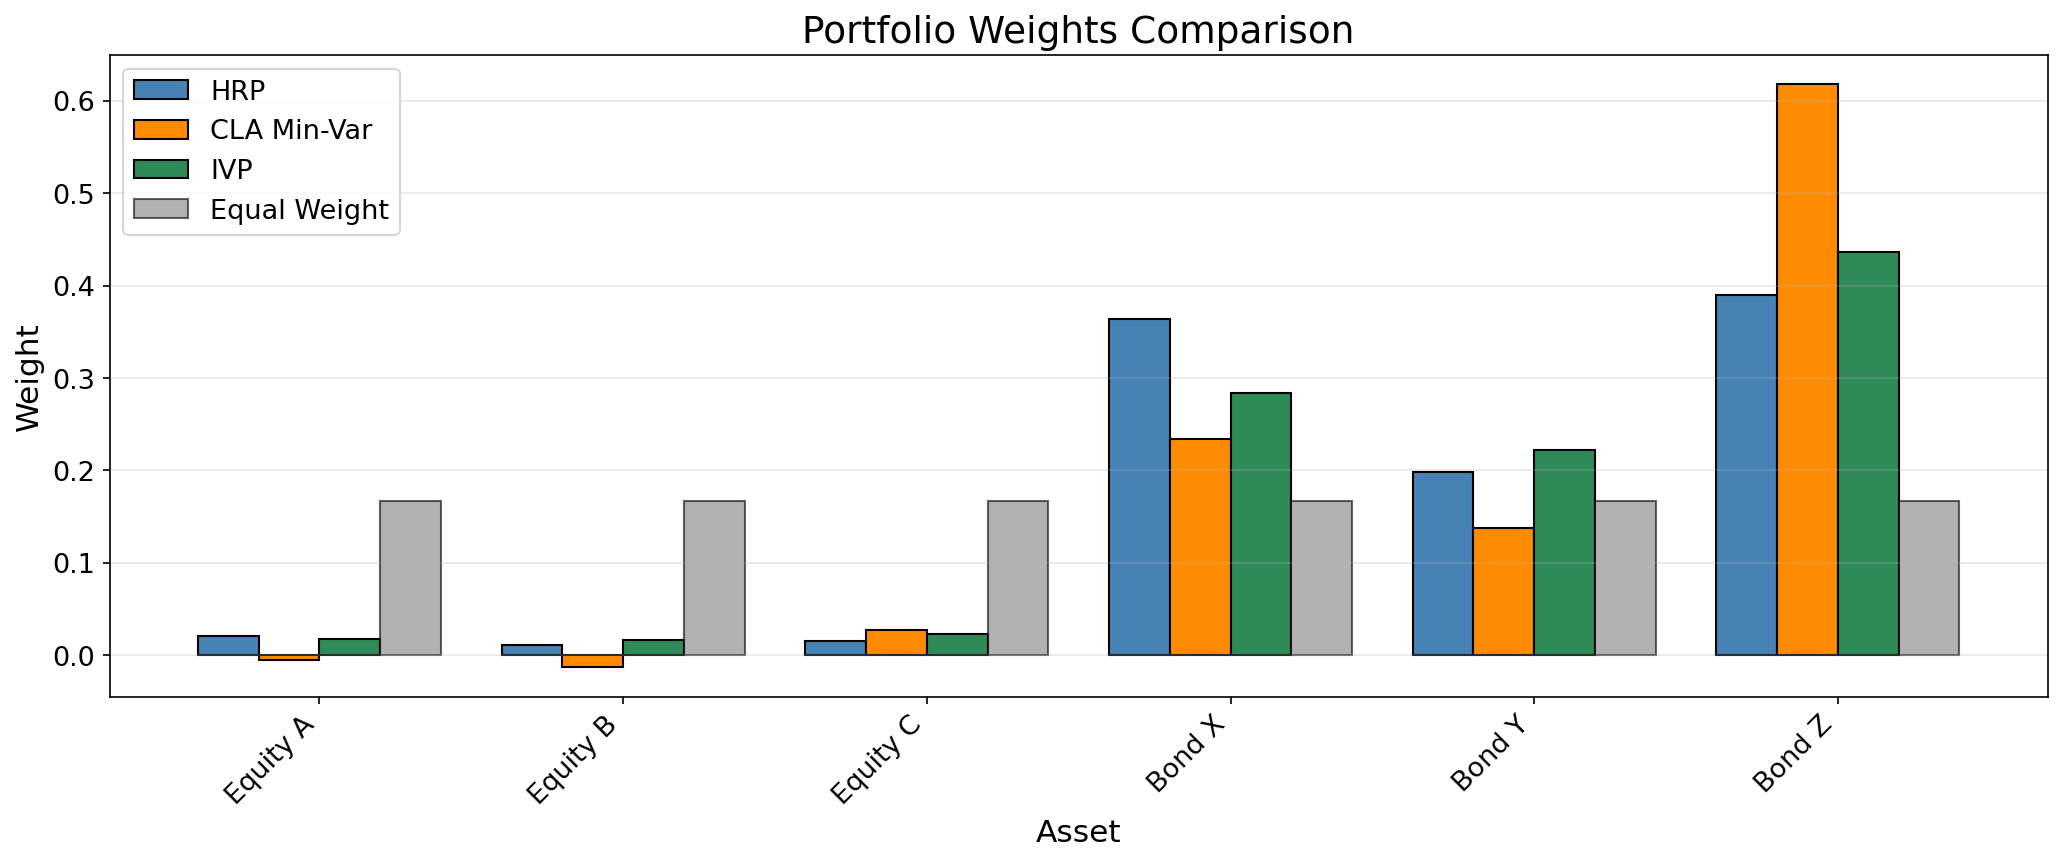

In [7]:
x = np.arange(n_assets)
width = 0.2
eq_w = np.ones(n_assets) / n_assets

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, hrp_w, width, label='HRP', color='steelblue', edgecolor='black')
ax.bar(x - 0.5*width, cla_minvar, width, label='CLA Min-Var', color='darkorange', edgecolor='black')
ax.bar(x + 0.5*width, ivp_w, width, label='IVP', color='seagreen', edgecolor='black')
ax.bar(x + 1.5*width, eq_w, width, label='Equal Weight', color='gray', edgecolor='black', alpha=0.6)

ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.set_title('Portfolio Weights Comparison')
ax.set_xticks(x)
ax.set_xticklabels(asset_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## In-Sample Performance

Compare the portfolio-level returns for each allocation method on
the same data used to compute the weights.

In [8]:
methods = {
    'HRP': hrp_w,
    'CLA Min-Var': cla_minvar,
    'CLA Max-SR': cla_maxsr,
    'IVP': ivp_w,
    'Equal Weight': eq_w,
}

print(f"{'Method':>15} {'Ann. Return':>12} {'Ann. Vol':>10} {'Sharpe':>8} {'Max DD':>8}")
print(f"{'-'*15:>15} {'-'*12:>12} {'-'*10:>10} {'-'*8:>8} {'-'*8:>8}")

port_returns = {}
for name, w in methods.items():
    pr = returns @ w
    port_returns[name] = pr
    ann_ret = np.mean(pr) * 252
    ann_vol = np.std(pr) * np.sqrt(252)
    sr = pymlfinance.backtesting.sharpe_ratio(pr)
    dd = pymlfinance.backtesting.compute_drawdowns(pr)
    print(f"{name:>15} {ann_ret:>12.2%} {ann_vol:>10.2%} {sr:>8.4f} {dd.max_drawdown:>8.2%}")

         Method  Ann. Return   Ann. Vol   Sharpe   Max DD
--------------- ------------ ---------- -------- --------
            HRP        5.89%      3.84%   1.5318    3.70%
    CLA Min-Var        5.71%      3.68%   1.5517    3.31%
     CLA Max-SR       17.11%      6.36%   2.6864    3.91%
            IVP        6.11%      3.83%   1.5932    3.61%
   Equal Weight       13.58%      9.06%   1.4967    8.78%


### Visualisation: Cumulative Returns

Cumulative wealth paths show how the different allocations perform
over the sample period.

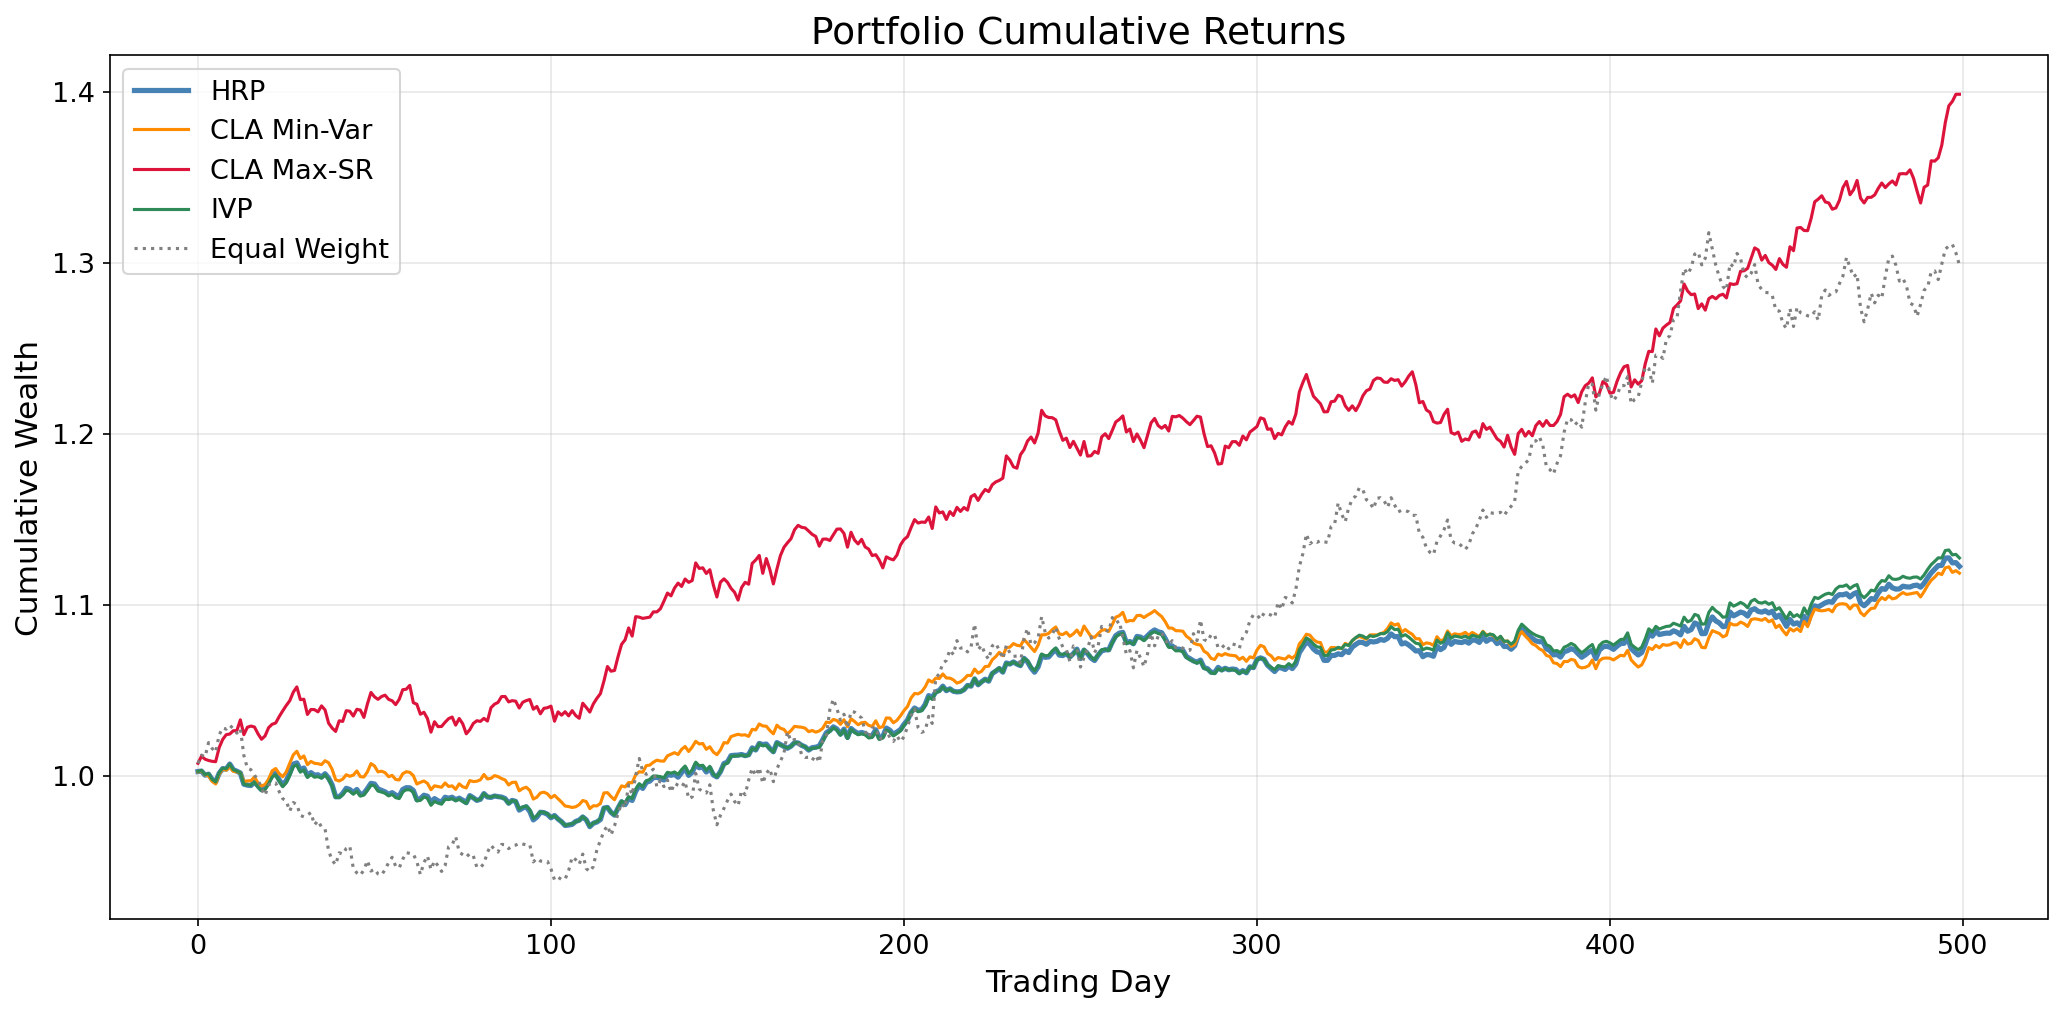

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen', 'gray']

for (name, pr), color in zip(port_returns.items(), colors):
    cum = np.cumprod(1 + pr)
    lw = 2.5 if name == 'HRP' else 1.5
    ls = '-' if name != 'Equal Weight' else ':'
    ax.plot(cum, linewidth=lw, linestyle=ls, color=color, label=name)

ax.set_xlabel('Trading Day')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Portfolio Cumulative Returns')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Monte Carlo Comparison

A single in-sample comparison can be misleading. The Monte Carlo
comparison function resamples the data many times to compare
out-of-sample Sharpe ratios and portfolio variances across methods.

In [10]:
mc = pymlfinance.features.compare_allocations(returns, n_simulations=100, seed=42)

print("Monte Carlo Comparison (100 simulations)")
print("=" * 45)
print(f"{'Method':>10} {'Avg Sharpe':>12} {'Avg Variance':>14}")
print(f"{'-'*10:>10} {'-'*12:>12} {'-'*14:>14}")
print(f"{'HRP':>10} {mc.hrp_sharpe:>12.4f} {mc.hrp_variance:>14.6f}")
print(f"{'CLA':>10} {mc.cla_sharpe:>12.4f} {mc.cla_variance:>14.6f}")
print(f"{'IVP':>10} {mc.ivp_sharpe:>12.4f} {mc.ivp_variance:>14.6f}")

Monte Carlo Comparison (100 simulations)
    Method   Avg Sharpe   Avg Variance
---------- ------------ --------------
       HRP       0.0610       0.000032
       CLA       0.0610       0.000032
       IVP       0.0846       0.000033


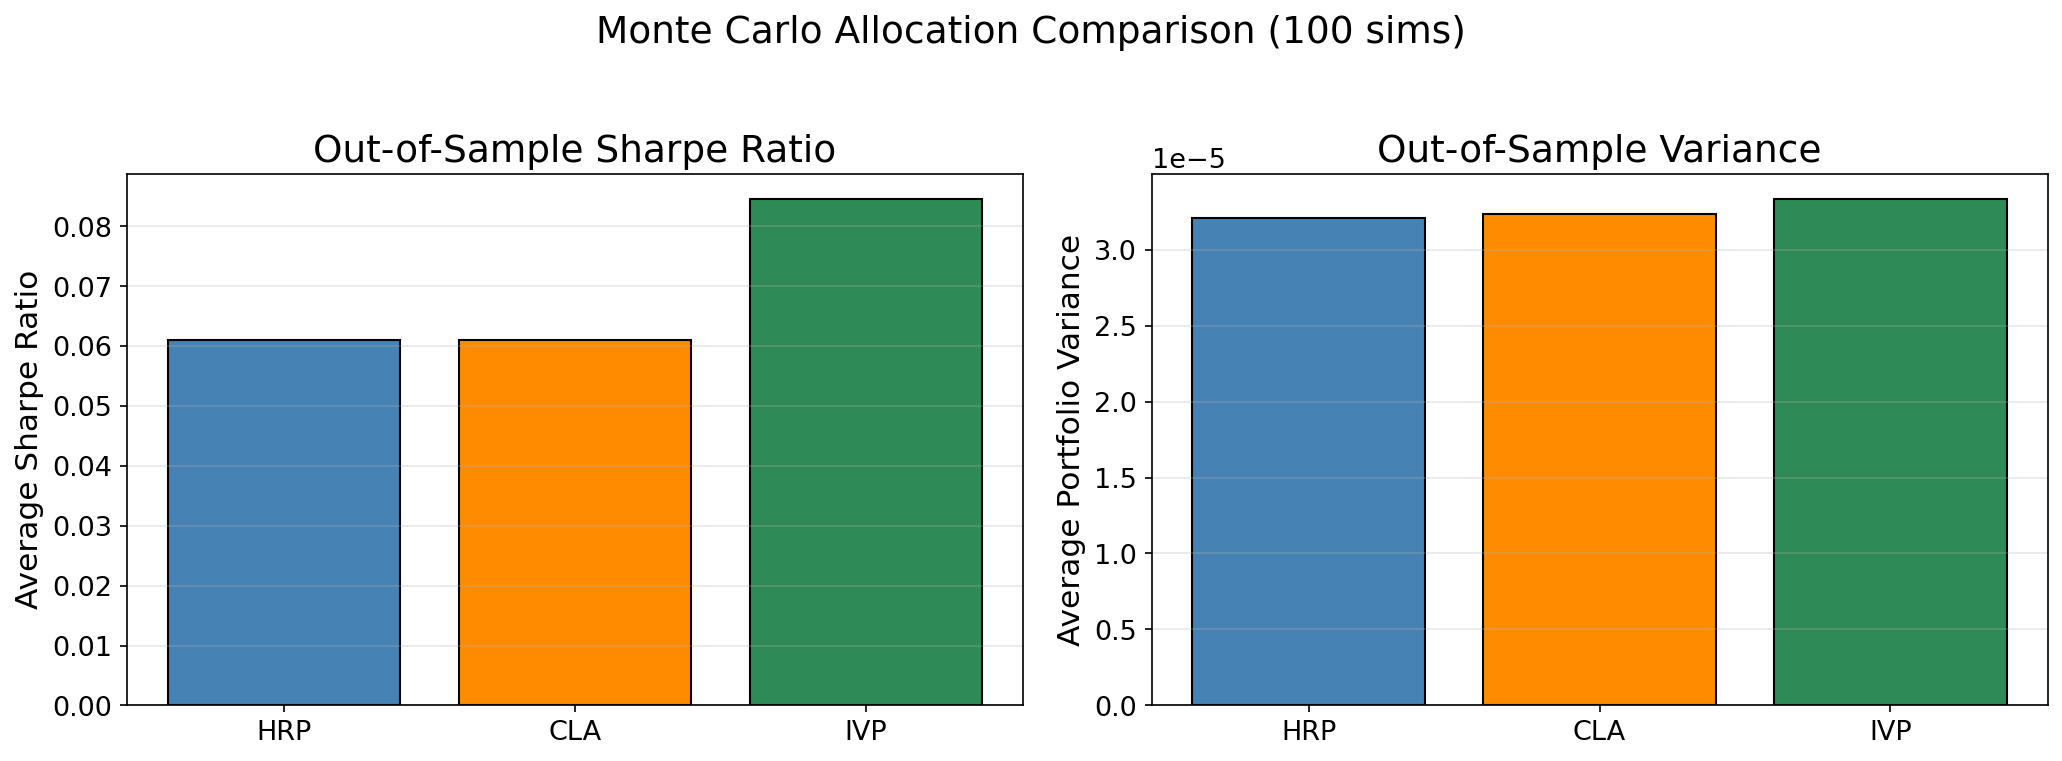

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe comparison
method_names = ['HRP', 'CLA', 'IVP']
sharpes = [mc.hrp_sharpe, mc.cla_sharpe, mc.ivp_sharpe]
variances = [mc.hrp_variance, mc.cla_variance, mc.ivp_variance]
colors = ['steelblue', 'darkorange', 'seagreen']

axes[0].bar(method_names, sharpes, color=colors, edgecolor='black')
axes[0].set_ylabel('Average Sharpe Ratio')
axes[0].set_title('Out-of-Sample Sharpe Ratio')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(method_names, variances, color=colors, edgecolor='black')
axes[1].set_ylabel('Average Portfolio Variance')
axes[1].set_title('Out-of-Sample Variance')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Monte Carlo Allocation Comparison (100 sims)', y=1.02)
plt.tight_layout()
plt.show()

## Sensitivity to Noise

HRP's key advantage is stability under estimation error. Here we
add increasing noise to the covariance matrix and compare how
much the weights change for each method.

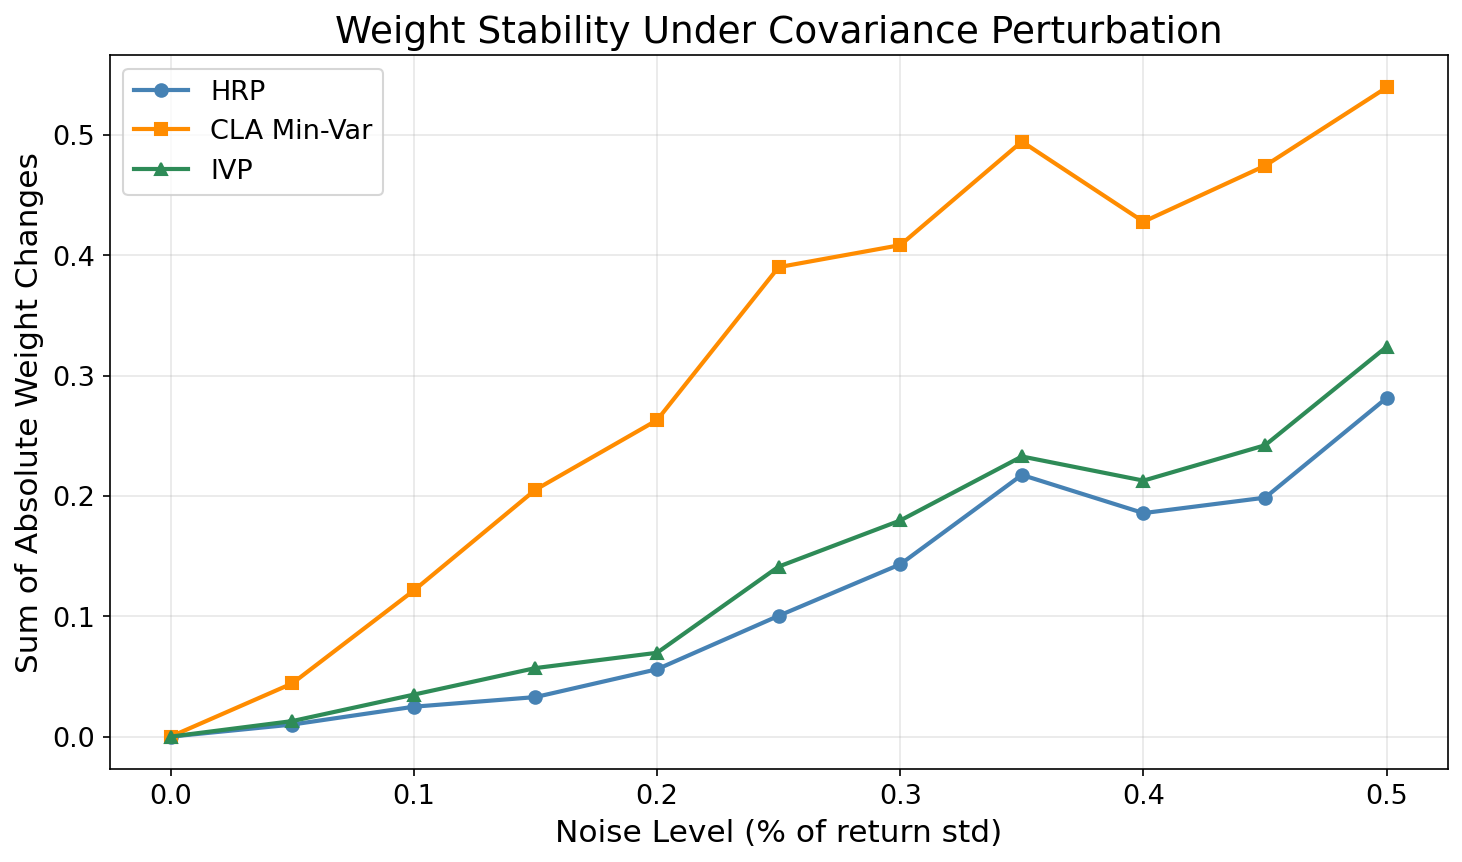

In [12]:
noise_levels = np.linspace(0, 0.005, 11)
hrp_diffs = []
cla_diffs = []
ivp_diffs = []

for noise in noise_levels:
    perturbed = returns + np.random.randn(*returns.shape) * noise
    perturbed_cov = np.cov(perturbed.T)

    w_hrp = pymlfinance.features.hrp_weights(perturbed)
    w_cla = pymlfinance.features.cla_min_variance(perturbed_cov)
    w_ivp = pymlfinance.features.inverse_variance_weights(perturbed_cov)

    hrp_diffs.append(np.sum(np.abs(w_hrp - hrp_w)))
    cla_diffs.append(np.sum(np.abs(w_cla - cla_minvar)))
    ivp_diffs.append(np.sum(np.abs(w_ivp - ivp_w)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(noise_levels * 100, hrp_diffs, 'o-', linewidth=2, label='HRP', color='steelblue')
ax.plot(noise_levels * 100, cla_diffs, 's-', linewidth=2, label='CLA Min-Var', color='darkorange')
ax.plot(noise_levels * 100, ivp_diffs, '^-', linewidth=2, label='IVP', color='seagreen')
ax.set_xlabel('Noise Level (% of return std)')
ax.set_ylabel('Sum of Absolute Weight Changes')
ax.set_title('Weight Stability Under Covariance Perturbation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

1. Increase the number of assets to 20 and observe how HRP handles the higher-dimensional problem.
2. Reduce the sample size to 50 periods and compare allocation stability.
3. Add a single highly volatile asset and compare how each method allocates to it.